In [2]:
# Importing TensorFlow
import tensorflow as tf
# Loading the data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Data preprocessing (here, normalization)
x_train, x_test = x_train / 255.0, x_test / 255.0
# Building the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])
# Loss function declaration
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# Model compilation
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])
# Training
model.fit(x_train, y_train, epochs=5)


/home/eshrath/weviate/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1742889809.998679 1981281 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1743 MB memory:  -> device: 0, name: NVIDIA GeForce MX230, pci bus id: 0000:01:00.0, compute capability: 6.1
2025-03-25 13:33:34.620574: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.
2025-03-25 13:33:34.990088: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5


I0000 00:00:1742889817.381823 1994441 service.cc:148] XLA service 0x71dfe0002c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742889817.382542 1994441 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce MX230, Compute Capability 6.1
2025-03-25 13:33:37.498766: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742889817.703215 1994441 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-25 13:33:39.674165: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


  17/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.2371 - loss: 2.1410

I0000 00:00:1742889821.019911 1994441 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8619 - loss: 0.4731
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9573 - loss: 0.1489
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9674 - loss: 0.1048
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9737 - loss: 0.0837
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9768 - loss: 0.0747


In [3]:
model(x_test[:2])

<tf.Tensor: shape=(2, 10), dtype=float32, numpy=
array([[ -9.188817  ,  -6.5367517 ,  -0.52893317,   4.13592   ,
        -12.693926  ,  -2.509008  , -23.208607  ,  12.231248  ,
         -6.7698193 ,  -2.385287  ],
       [ -9.106843  ,   5.1370745 ,  12.243746  ,   1.3433858 ,
        -22.253002  ,   0.59319115,  -8.029045  , -16.263702  ,
         -5.58918   , -19.035011  ]], dtype=float32)>

In [4]:
model.save('mymodel.keras')

In [5]:
model.export('./mymodel/1/')

INFO:tensorflow:Assets written to: ./mymodel/1/assets


INFO:tensorflow:Assets written to: ./mymodel/1/assets


Saved artifact at './mymodel/1/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  125210690704256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125210690709184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125213089036272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125210690834272: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [3]:
model = tf.saved_model.load('/home/eshrath/weviate/tensorflow_k8s/mymodel/1')

I0000 00:00:1742974690.052859  973571 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1743 MB memory:  -> device: 0, name: NVIDIA GeForce MX230, pci bus id: 0000:01:00.0, compute capability: 6.1


In [18]:
import requests
import numpy as np
import json
import tensorflow as tf

# Loading data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Data preprocessing (here, normalization)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Format the image data so as to be sent as JSON
payload = json.dumps({'instances': x_test[:2].tolist()})

# URL of the TensorFlow Serving container's API
url = 'http://localhost:8501/v1/models/mymodel:predict'

# Send the request
response = requests.post(url, data=payload)

# Print the full response and status code
print(response.text)
print(response.status_code)

# Parse the response
try:
    prediction = response.json()["predictions"]
    print("Predictions:")
    print(prediction)
except KeyError as e:
    print(f"KeyError: {e}")
    print("Full response content:")
    print(response.text)

{
    "predictions": [[-9.18881607, -6.53675079, -0.528933108, 4.13591957, -12.6939268, -2.50900769, -23.2086067, 12.231246, -6.76982, -2.385288], [-9.10684299, 5.13707399, 12.2437458, 1.34338534, -22.2530022, 0.593190789, -8.02904415, -16.2637043, -5.58918, -19.0350113]
    ]
}
200
Predictions:
[[-9.18881607, -6.53675079, -0.528933108, 4.13591957, -12.6939268, -2.50900769, -23.2086067, 12.231246, -6.76982, -2.385288], [-9.10684299, 5.13707399, 12.2437458, 1.34338534, -22.2530022, 0.593190789, -8.02904415, -16.2637043, -5.58918, -19.0350113]]


for custom image

In [17]:
from PIL import Image
import numpy as np
import requests
import json

def prepare_image(file_path):
    # Open the image
    with Image.open(file_path) as img:
        # Convert to grayscale
        img = img.convert('L')
        # Resize to 28x28
        img = img.resize((28, 28))
        # Convert to numpy array and normalize
        img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array


custom_image = prepare_image('/home/eshrath/weviate/2.jpg')  

# Prepare the payload
payload = json.dumps({
    'instances': [custom_image.tolist()]  # Send as a list of instances
})

# URL of the TensorFlow Serving container's API
url = 'http://localhost:8501/v1/models/mymodel:predict'

# Send the request
response = requests.post(url, data=payload)

# Print the full response and status code
print("Response status code:", response.status_code)
print("Full response content:")
print(response.text)

# Parse the response
try:
    prediction = response.json()["predictions"][0]
    print("\nPredictions:")
    print(prediction)
    
    # Get the predicted digit (assumes output is a list of probabilities)
    predicted_digit = np.argmax(prediction)
    confidence = prediction[predicted_digit]
    print(f"\nPredicted digit: {predicted_digit}")
    print(f"Confidence: {confidence:.2f}")

except KeyError as e:
    print(f"KeyError: {e}")
    print("Failed to parse predictions from the response.")
except json.JSONDecodeError:
    print("Failed to decode JSON from the response.")
except Exception as e:
    print(f"An error occurred: {e}")

Response status code: 200
Full response content:
{
    "predictions": [[-26.8045959, -33.1492157, 1.75443661, 15.7880945, -74.0126343, 16.6309376, -14.5215654, 16.6600246, -20.7589741, -45.9350586]
    ]
}

Predictions:
[-26.8045959, -33.1492157, 1.75443661, 15.7880945, -74.0126343, 16.6309376, -14.5215654, 16.6600246, -20.7589741, -45.9350586]

Predicted digit: 7
Confidence: 16.66


In [ ]:
import requests
import numpy as np
import json
import tensorflow as tf

# Loading data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Data preprocessing (here, normalization)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Format the image data so as to be sent as JSON
payload = json.dumps({'instances': x_test[:2].tolist()})

# URL of the TensorFlow Serving container's API
url = 'http://localhost:8501/v1/models/mymodel:predict'

# Send the request
payload = json.dumps({'instances': ["test_string"]})
response = requests.post(url, data=payload)
print(response.text)
print(response.status_code)

# Parse the response
prediction = response.json()["predictions"]

# Print the result
print(prediction)


In [ ]:
import requests
import numpy as np
import tensorflow as tf
import json

# Function to create adversarial examples using FGSM
def create_adversarial_example(input_image, input_label, epsilon=0.1):
    # Convert the input image and label to tensors
    input_image = tf.convert_to_tensor(input_image, dtype=tf.float32)
    input_label = tf.convert_to_tensor(input_label, dtype=tf.int64)
    
    # URL of the TensorFlow Serving container's API 
    url = 'http://localhost:8501/v1/models/mymodel:predict'
    
    # Convert tensor to NumPy array and then to Python list
    input_image_numpy = input_image.numpy()
    input_image_list = input_image_numpy.tolist()
    
    # Format the image data to be sent as JSON
    payload = json.dumps({'instances': input_image_list})
    
    # Send the request to get model's prediction
    response = requests.post(url, data=payload)
    prediction = np.array(response.json()["predictions"])
    
    # Calculate the loss
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        
        prediction = model(input_image)
        loss = tf.keras.losses.sparse_categorical_crossentropy(input_label, prediction)

    # Get the gradient of the loss w.r.t the input image
    gradient = tape.gradient(loss, input_image)
    
    # Get the sign of the gradient
    signed_grad = tf.sign(gradient)
    
    # Create the adversarial image by adjusting the input image in the direction of the gradient
    adversarial_image = input_image + epsilon * signed_grad
    
    # Convert adversarial image tensor back to numpy array
    adversarial_image = adversarial_image.numpy()
    
    return adversarial_image

# Select a sample from the test dataset
sample_index = 0
sample_image = x_test[sample_index:sample_index+3]
sample_label = y_test[sample_index:sample_index+3]

# Create an adversarial example
adversarial_image = create_adversarial_example(sample_image, sample_label)

# Predict the class of the adversarial example
adversarial_prediction = model.predict(adversarial_image)

# Print the results
print("Original label:", sample_label)
print("Adversarial prediction:", np.argmax(adversarial_prediction, axis=1))


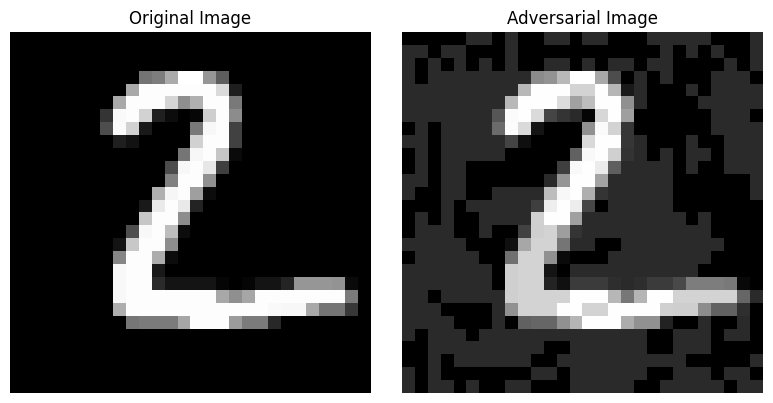

In [18]:
import matplotlib.pyplot as plt

# Assuming sample_image and adversarial_image are already defined
plt.figure(figsize=(8, 4))

# Original image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image[1], cmap='gray')
plt.axis('off')

# Adversarial image
plt.subplot(1, 2, 2)
plt.title("Adversarial Image")
plt.imshow(adversarial_image[1], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [3]:
import pickle
with open("/home/eshrath/weviate/tensorflow_k8s/sample_model_scan_test.py", "r") as f:
    code = f.read()

with open("code_model_scanu.pkl", "wb") as f:
    pickle.dump(code, f)
